In [2]:
library(cluster)
library(ggplot2)

Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang


In [3]:
data <- iris
df <- data[, 1:4]
df_scaled <- scale(df)

In [4]:
set.seed(123)
km_res <- kmeans(df_scaled, centers = 3, nstart = 25)

In [5]:
dist_matrix <- dist(df_scaled, method = "euclidean")
hclust_res <- hclust(dist_matrix, method = "ward.D2")
h_clusters <- cutree(hclust_res, k = 3)

In [6]:
wss <- sapply(1:10, function(k){
  kmeans(df_scaled, centers = k, nstart = 20)$tot.withinss
})

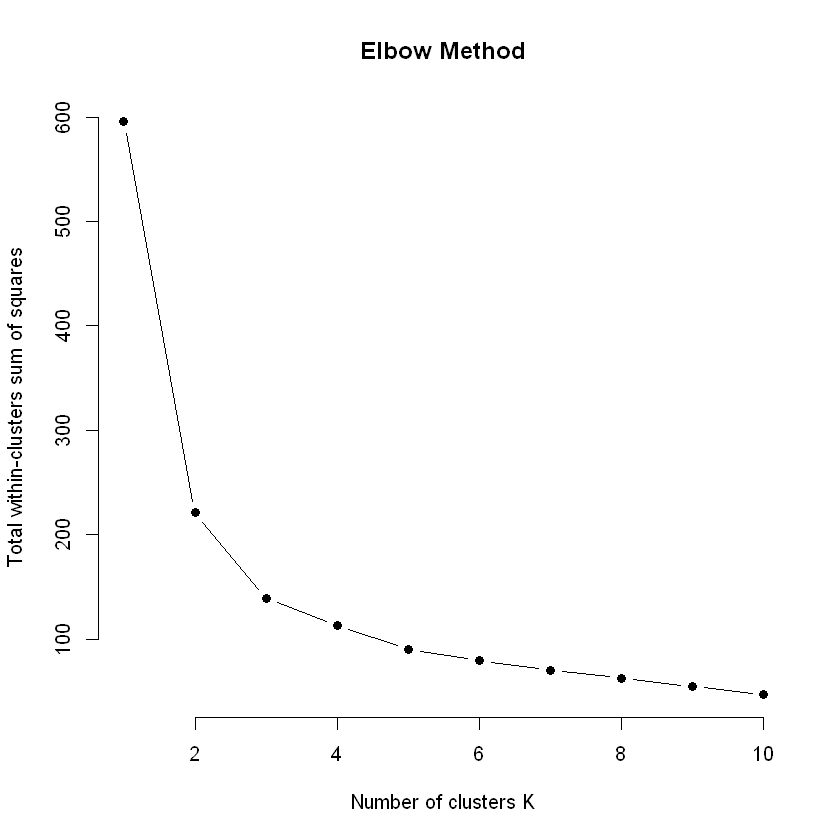

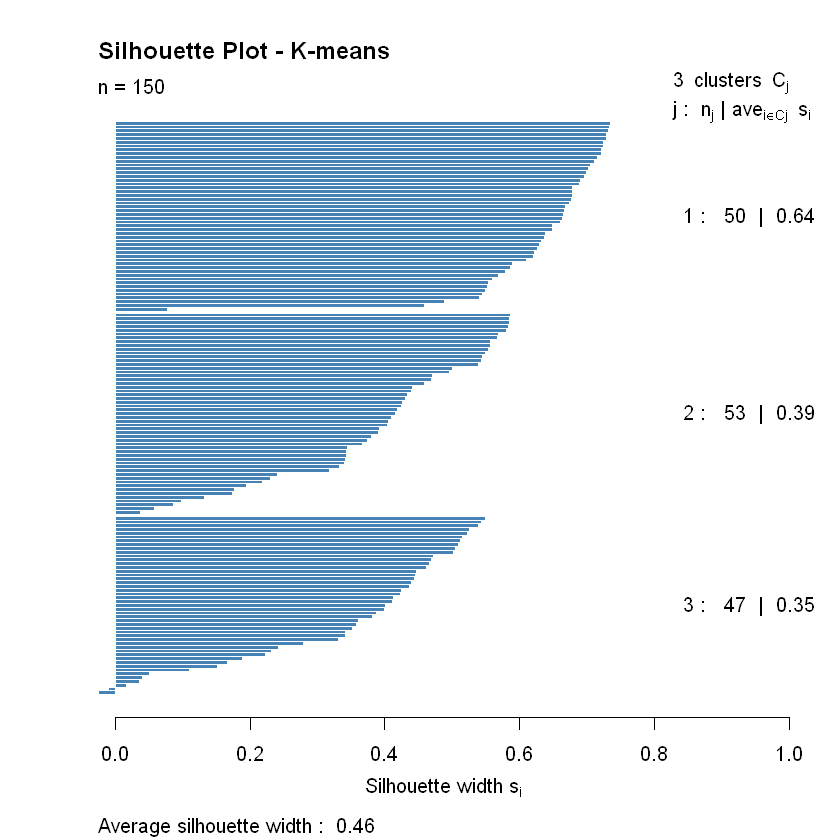

In [7]:
plot(1:10, wss, type="b", pch = 19, frame = FALSE, 
     xlab="Number of clusters K",
     ylab="Total within-clusters sum of squares",
     main="Elbow Method")

sil <- silhouette(km_res$cluster, dist(df_scaled))
plot(sil, main = "Silhouette Plot - K-means", col = "steelblue")

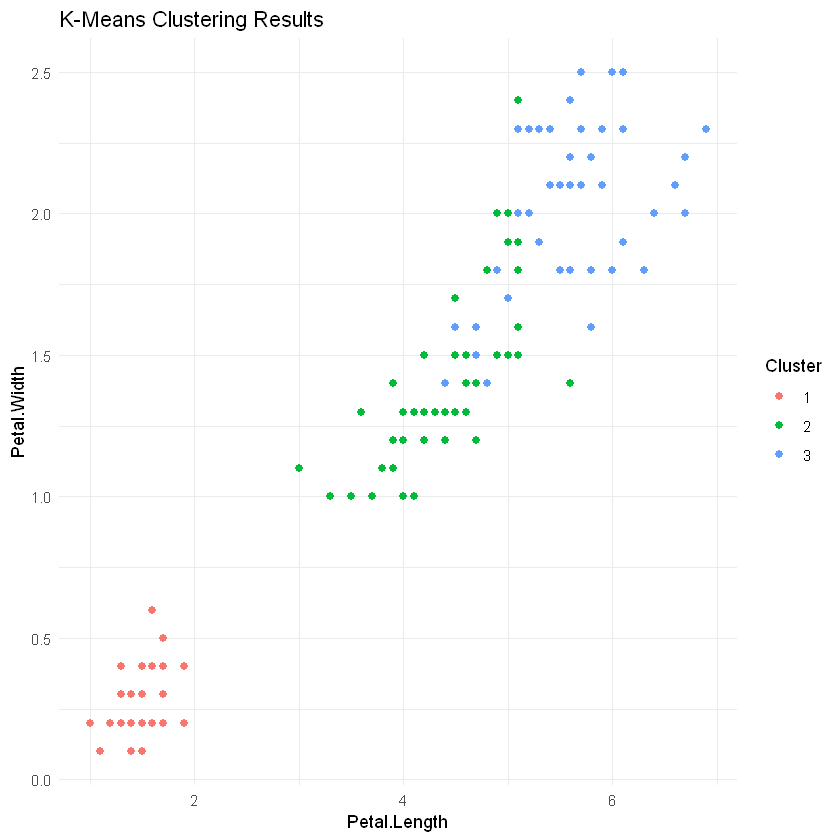

In [8]:
ggplot(df, aes(Petal.Length, Petal.Width, color = as.factor(km_res$cluster))) +
  geom_point(size = 2) +
  labs(title = "K-Means Clustering Results", color = "Cluster") +
  theme_minimal()